In [1]:
import pickle as pkl
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import ot
from sklearn.preprocessing import QuantileTransformer
from scipy.stats import wasserstein_distance
import pandas as pd

In [2]:
all_eids_engagement_signal = pkl.load(open("../data/generated/all_eids_engagement.pkl", "rb"))

In [26]:
def find_top_sessions(engagement_signal_dict, target_eid, top_n=5):
    distances = []
    target_distribution = engagement_signal_dict[target_eid]
    for eid, engagement in engagement_signal_dict.items():
        if eid == target_eid:
            continue
        source_distribution = engagement_signal_dict[eid]
        w_dist = wasserstein_distance(source_distribution, target_distribution)
        distances.append({"session_id": eid, "distance": w_dist})
    df = pd.DataFrame(distances)
    df = df.sort_values(by="distance")
    return df.reset_index()

In [27]:
target_eid = "004d8fd5-41e7-4f1b-a45b-0d4ad76fe446"

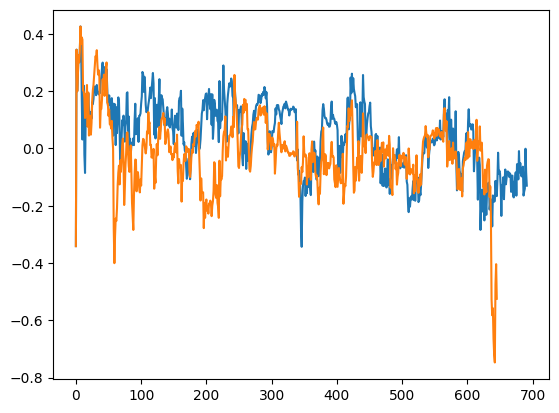

In [4]:
plt.plot(all_eids_engagement_signal["004d8fd5-41e7-4f1b-a45b-0d4ad76fe446"])

plt.plot(all_eids_engagement_signal["02fbb6da-3034-47d6-a61b-7d06c796a830"])

In [28]:
df = find_top_sessions(all_eids_engagement_signal, target_eid)

In [31]:
source_eid = df["session_id"][0]

In [21]:
ot_mapper = ot.da.EMDTransport()

In [33]:
target = np.asarray(all_eids_engagement_signal[target_eid]).reshape(-1, 1)
source = np.asarray(all_eids_engagement_signal[source_eid]).reshape(-1, 1)

In [61]:
def generate_null_with_emd_transport(target_signal, source_signal):
    """
    Requires Source to be >= Target in length.
    """
    target_signal = np.asarray(target_signal).flatten()
    source_signal = np.asarray(source_signal).flatten()

    N = len(target_signal)
    M = len(source_signal)

    if M < N:
        raise ValueError(f"Source ({M}) must be >= Target ({N}) for slicing.")

    source_slice = source_signal[:N]

    valid_target_mask = ~np.isnan(target_signal)
    valid_source_mask = ~np.isnan(source_slice)

    clean_target = target_signal[valid_target_mask].reshape(-1, 1)
    clean_source = source_slice[valid_source_mask].reshape(-1, 1)

    ot_mapper = ot.da.EMDTransport()
    ot_mapper.fit(Xs=clean_source, Xt=clean_target)
    transformed_clean_source = ot_mapper.transform(Xs=clean_source).flatten()

    final_null_signal = np.full(N, np.nan)
    final_null_signal[valid_source_mask] = transformed_clean_source

    return final_null_signal

In [62]:
perm_signal = generate_null_with_emd_transport(target, source)

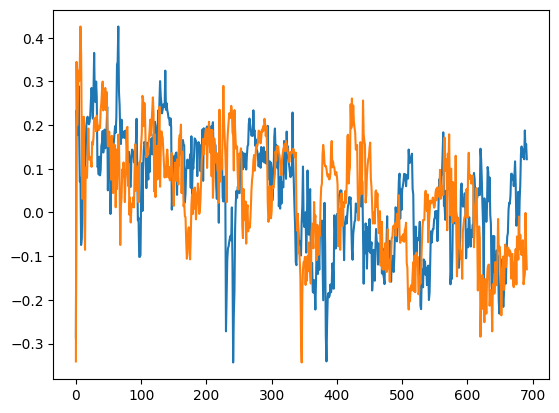

In [67]:
plt.plot(perm_signal)
plt.plot(target)